# **INIT_COMBINE LOOP SCRIPT**

In [1]:
#STEP 1: IMPORTS
#Load this first

import warnings
import scanpy as sc
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import doubletdetection
import soupx
import harmonypy as hm
import decoupler as dc
import scvi
from IPython.display import clear_output 
import re
import os
import time
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

warnings.filterwarnings('ignore')
ad.settings.allow_write_nullable_strings = True
pd.options.future.infer_string = False
pd.reset_option("all")
%matplotlib inline

#COLOR DEFINITIONS
infected_colors = {
    "infected": "#582B36",
    "uninfected": "#582B36"
}

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)

marker_genes = {
    "T Cells": ["Cd3e"],
    "B Cells": ["Cd19", "Cd74"],
    "Absorptive Colonocytes": ["Slc26a3","Aqp4","Aqp8","Cyp2c55","Car1"],
    "Enteroendocrine Cells": ["Neurod1","Chga","Chgb"],
    "Stem Cells": ["Lgr5","Nox1","Ascl2"],
    "Transit Amplifying Cells": ["Mki67","Top2a","Ube2c"],
    "Goblet Cells": ["Muc2","Zg16","Tff3","Spink4"],
    "Tuft Cells": ["Dclk1"],
    "Mast Cells": ["Mcpt1","Mcpt2"]
}
res_list = [0.20, 0.50, 0.75, 1.00]

/projects/hvose@xsede.org/software/anaconda/envs/jupyter_scrna/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# STEP 2: Load Data
diet_combine = sc.read_h5ad("data/20260731_diet_reannotated.h5ad")
live_redo = sc.read_h5ad("data/20260731_live_reannotated.h5ad")

In [3]:
for val in range(1,17):
    match val:
            case val if 1<=int(val)<=5:
                diet_combine.obs.loc[diet_combine.obs["sample"] == f"sample_{val}", 'treatment'] = 'fiber'
            case val if 6<=int(val)<=10:
                diet_combine.obs.loc[diet_combine.obs["sample"] == f"sample_{val}", 'treatment'] = 'amp'
            case _:
                diet_combine.obs.loc[diet_combine.obs["sample"] == f"sample_{val}", 'treatment'] = '3DPI'

In [4]:
for val in range(1,4):
    live_redo.obs.loc[live_redo.obs["sample"] == f"MHVY_Colon_5dpi_{val}", 'treatment'] = '5DPI'
    live_redo.obs.loc[live_redo.obs["sample"] == f"Uninfected_{val}", 'treatment'] = 'Mock'

In [5]:
print(diet_combine.obs["treatment"])
print(live_redo.obs["treatment"])

AAACAAGCAACAAGTTACTTTAGG-1    fiber
AAACAAGCAAGAACAAACTTTAGG-1    fiber
AAACAAGCACATAAACACTTTAGG-1    fiber
AAACAAGCACCACAAAACTTTAGG-1    fiber
AAACAAGCAGTTGCCCACTTTAGG-1    fiber
                              ...  
TTTGTGAGTAACCTTAATTCGGTT-1     3DPI
TTTGTGAGTACGAATGATTCGGTT-1     3DPI
TTTGTGAGTCACAGAAATTCGGTT-1     3DPI
TTTGTGAGTTCTCAAAATTCGGTT-1     3DPI
TTTGTGAGTTTATGGCATTCGGTT-1     3DPI
Name: treatment, Length: 104677, dtype: str
AAACCATTCAGGATGG    5DPI
AAACCATTCGCGTTCC    5DPI
AAACCCTGTAAGTGGC    5DPI
AAACCCTGTAGCCTCA    5DPI
AAACCCTGTTAGCGCC    5DPI
                    ... 
TGTGTTAGTTGAGGTA    Mock
TGTGTTGAGATAGTAG    Mock
TGTGTTGAGATTGCTG    Mock
TGTGTTGAGGAATGAC    Mock
TGTGTTGAGGGTGACA    Mock
Name: treatment, Length: 57853, dtype: str


## **Cluster Labeling**

In [ ]:
sc.pl.umap(live_redo, color="sample")

In [ ]:
# STEP 3: Get PCs and batch unmix the data
sc.pp.pca(live_redo)
sc.pp.pca(diet_combine)
pcs_l = live_redo.obsm['X_pca']
pcs_d = diet_combine.obsm['X_pca']
#print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out_l = hm.run_harmony(pcs_l, live_redo.obs, "sample",max_iter_harmony=25)
harmony_out_d = hm.run_harmony(pcs_d, diet_combine.obs, "sample",max_iter_harmony=25)


print("finished harmony")

# Store corrected PCs back in the AnnData object
live_redo.obsm['X_pca_harmony'] = harmony_out_l.Z_corr
diet_combine.obsm['X_pca_harmony'] = harmony_out_d.Z_corr
sc.pp.neighbors(live_redo, use_rep='X_pca_harmony')
sc.pp.neighbors(diet_combine, use_rep='X_pca_harmony')
sc.tl.umap(live_redo)
sc.tl.umap(diet_combine)

In [ ]:
%matplotlib inline
sc.pl.umap(live_redo, color=["sample","init_annotation"])
sc.pl.umap(diet_combine, color=["sample","init_annotation"])

In [ ]:
sc.pp.highly_variable_genes(
    diet_combine, n_top_genes=4000, flavor="seurat_v3", subset=False, layer="counts"
)
sc.pp.highly_variable_genes(
    live_redo, n_top_genes=4000, flavor="seurat_v3", subset=False, layer="counts"
)

In [ ]:
res_list = [0.50,0.75,1.00,1.50,2.00,2.50]

for res in res_list:
    sc.tl.leiden(diet_combine, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")
    sc.tl.leiden(live_redo, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

In [ ]:

sc.pl.umap(
    diet_combine,
    color=["leiden_res_0.50", "leiden_res_0.75", "leiden_res_1.00", "leiden_res_1.50","leiden_res_2.00","leiden_res_2.50"],
    legend_loc="on data",
)

In [ ]:
sc.pl.umap(
    live_redo,
    color=["leiden_res_0.50", "leiden_res_0.75", "leiden_res_1.00", "leiden_res_1.50","leiden_res_2.00","leiden_res_2.50"],
    legend_loc="on data",
)

In [ ]:
markers = ["Cd3e","Cd74","Slc26a3", "Aqp4", "Aqp8", "Cyp2c55", "Car1", "Chga", "Muc2", "Tff3", "Spink4", "Zg16", "Lgr5", "Ascl2", "Nox1", "Mki67", "Top2a", "Ube2c", "Dclk1"]
sc.tl.rank_genes_groups(diet_combine, groupby=f"leiden_res_2.00", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(diet_combine, groupby=f"leiden_res_2.00", standard_scale="var", n_genes=5,dendrogram=False)
sc.pl.heatmap(diet_combine,markers,groupby=f"leiden_res_2.00",figsize=(30,8),swap_axes=True)
sc.pl.umap(diet_combine,color=f"leiden_res_2.00",legend_loc="on data")

In [ ]:
markers = ["Cd3e","Cd74","Slc26a3", "Aqp4", "Aqp8", "Cyp2c55", "Car1", "Thbs4", "Ckmt1", "Hoxb13", "Chga", "Muc2", "Tff3", "Spink4", "Zg16", "Lgr5", "Ascl2", "Nox1", "Mki67", "Top2a", "Ube2c", "Dclk1"]
sc.pl.umap(diet_combine,color=markers)

In [ ]:
sc.pl.umap(diet_combine, color="init_annotation",size=20,mask_obs=(diet_combine.obs["leiden_res_2.00"] == "47"))

In [ ]:
#vague annotations - does NOT need to be highly specific

cluster2annotation = {
    "0": "Goblet Cells",
    "1": "Stem Cells",
    "2": "Goblet Cells",
    "3": "Absorptive Colonocytes",
    "4": "Goblet Cells",
    "5": "Goblet Cells",
    "6": "Goblet Cells",
    "7": "Absorptive Colonocytes",
    "8": "Immune Cells",
    "9": "Transit Amplifying Cells",
    "10": "Absorptive Colonocytes",
    "11": "Absorptive Colonocyte Progenitors",
    "12": "Goblet Cells",
    "13": "Goblet Cells",
    "14": "Transit Amplifying Cells",
    "15": "Absorptive Colonocytes",
    "16": "Absorptive Colonocytes",
    "17": "Enteroendocrine Cells",
    "18": "Absorptive Colonocytes",
    "19": "Transit Amplifying Cells",
    "20": "Goblet Cells",
    "21": "Goblet Cells",
    "22": "Absorptive Colonocytes",
    "23": "Goblet Cells",
    "24": "Goblet Cells",
    "25": "Stem Cells",
    "26": "Goblet Cells",
    "27": "Goblet Cells",
    "28": "Absorptive Colonocytes",
    "29": "Transit Amplifying Cells",
    "30": "Stem Cells",
    "31": "Transit Amplifying Cells",
    "32": "Goblet Cells",
    "33": "Tuft Cells",
    "34": "Goblet Cells",
    "35": "Goblet Cells",
    "36": "Enteroendocrine Cells",
    "37": "Absorptive Colonocytes",
    "38": "Immune Cells",
}

live_redo.obs['cluster_cell_type'] = live_redo.obs["leiden_res_2.00"].map(cluster2annotation).astype('category')

cluster2annotation_d = {
    "0": "Absorptive Colonocytes",
    "1": "Absorptive Colonocytes",
    "2": "Goblet Cells",
    "3": "Stem Cells",
    "4": "T Cells",
    "5": "Transit Amplifying Cells",
    "6": "Tuft Cells",
    "7": "Transit Amplifying Cells",
    "8": "Goblet Cells",
    "9": "Absorptive Colonocytes",
    "10": "Goblet Cells",
    "11": "B Cells",
    "12": "T Cells",
    "13": "Absorptive Colonocyte Progenitors",
    "14": "Goblet Cells",
    "15": "Absorptive Colonocyte Progenitors",
    "16": "Absorptive Colonocytes",
    "17": "Absorptive Colonocytes",
    "18": "Absorptive Colonocytes",
    "19": "Absorptive Colonocytes",
    "20": "Transit Amplifying Cells",
    "21": "Absorptive Colonocytes",
    "22": "Absorptive Colonocytes",
    "23": "Absorptive Colonocytes",
    "24": "T Cells",
    "25": "Absorptive Colonocytes",
    "26": "Enteroendocrine Cells",
    "27": "Goblet Cells",
    "28": "Absorptive Colonocytes",
    "29": "B Cells",
    "30": "T Cells",
    "31": "Absorptive Colonocytes",
    "32": "Goblet Cells",
    "33": "Goblet Cells",
    "34": "T Cells",
    "35": "Absorptive Colonocytes",
    "36": "Absorptive Colonocytes",
    "37": "Absorptive Colonocytes",
    "38": "Mast Cells",
    "39": "Tuft Cells",
    "40": "Enteroendocrine Cells",
    "41": "Transit Amplifying Cells",
    "42": "Absorptive Colonocyte Progenitors",
    "43": "Goblet Cells",
    "44": "Absorptive Colonocytes",
    "45": "RegFab Absorptive Colonocytes",
    "46": "Transit Amplifying Cells",
    "47": "Goblet/AC Mix"
}

diet_combine.obs['cluster_cell_type'] = diet_combine.obs["leiden_res_2.00"].map(cluster2annotation_d).astype('category')

In [ ]:
sc.pl.umap(diet_combine, color=["init_annotation","cluster_cell_type"])

In [ ]:
sc.pl.umap(live_redo, color=["init_annotation"])

In [ ]:
sc.pl.umap(live_redo,
           color=["init_annotation"],
           mask_obs=((live_redo.obs["init_annotation"] == "T_NK Cells") & (live_redo.obs["leiden_res_2.00"] == "47")),size=20)


In [ ]:
#reassignment block

live_redo.obs.loc[(live_redo.obs["init_annotation"] == "Stress_Inflamed"), "init_annotation"] = "Absorptive Colonocytes"

### Attempting to remove categories

In [ ]:
# print the cluster cell type of all remaining barcodes that are present in the init_annotation category, as well as specific gene expression values
print(live_redo.obs.loc[((live_redo.obs["init_annotation"] == "Stress_Inflamed")), ["leiden_res_2.00","cluster_cell_type"]])

sub_df = sc.get.obs_df(live_redo[live_redo.obs["init_annotation"] == "Stress_Inflamed"],keys=["Muc2","Car1","Nox1","Lgr5","leiden_res_2.00"])

In [ ]:
#reassignment block by loop

for idx, row in sub_df.iterrows():
    #print(f"{idx} and row is {row}")
    #print(f"is {row["Muc2"]} greater than {row["Car1"]}")
    if float(row["Muc2"]) > float(row["Car1"]):
        #print("should be gob")
        live_redo.obs.at[idx, "init_annotation"] = "Goblet Cells"
        #print(live_redo[idx].obs["init_annotation"])
    else:
        #print("should be ac")
        live_redo.obs.at[idx, "init_annotation"] = "Absorptive Colonocytes"
        #print(live_redo[idx].obs["init_annotation"])

In [ ]:
#attempt to remove empty categories
diet_combine.obs["init_annotation"].cat.categories

In [ ]:
#reassign newly removed categories to initial object

live_redo.obs["init_annotation"] = live_redo.obs["init_annotation"].cat.remove_unused_categories()

In [ ]:
#second writing block (post-combine)

live_redo.write_h5ad("20260731_live_reannotated.h5ad")
diet_combine.write_h5ad("20260731_diet_reannotated.h5ad")

In [96]:
aggregated

AnnData object with n_obs × n_vars = 14 × 8497
    obs: 'init_annotation'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    layers: 'mean'

In [ ]:
all_vars = list(my_var.upper() for my_var in diet_combine.var_names)

for var_name in all_vars:
    il_match = re.search(f"H2-",var_name)
    if il_match is not None:
        try:
            sc.pl.umap(diet_combine, color=var_name,frameon=False)
        except KeyError as e:
            print(f"idk why but {var_name} isn't here")

In [100]:
# 1. Calculate the mean expression per cluster
# Replace 'leiden' with your specific cluster column name (e.g., 'louvain', 'cell_type')
aggregated = sc.get.aggregate(diet_combine, by="init_annotation", func="mean")

print(aggregated.layers['mean'])

# 2. Extract into a clean, readable Pandas DataFrame
# Rows will be clusters, columns will be genes
df_mean_expr = sc.get.obs_df(aggregated)

# 3. Transpose if you prefer genes as rows and clusters as columns
df_mean_expr = df_mean_expr.T
print(df_mean_expr.head())

[[0.30389747 0.28959561 0.25534058 ... 0.14793046 1.29858707 0.18285495]
 [0.22101969 0.13793841 0.13016565 ... 0.05148192 0.73424823 0.09978124]
 [0.17545518 0.25879624 0.15831181 ... 0.27170126 1.11016534 0.08227123]
 ...
 [0.19979198 0.31129586 0.22559111 ... 0.2952312  1.22405103 0.11913708]
 [0.32005317 0.40703976 0.26716159 ... 0.20261977 1.19458612 0.21525745]
 [0.23762295 0.26241272 0.30691358 ... 0.13620205 1.09499919 0.17487721]]
Empty DataFrame
Columns: [Absorptive Colonocyte Progenitors, Absorptive Colonocytes, B Cells, Enteroendocrine Cells, Erythrocytes, Fibroblasts, Goblet Cells, Mast Cells, NK Cells, RegFab Absorptive Colonocytes, Stem Cells, T Cells, Transit Amplifying Cells, Tuft Cells]
Index: []


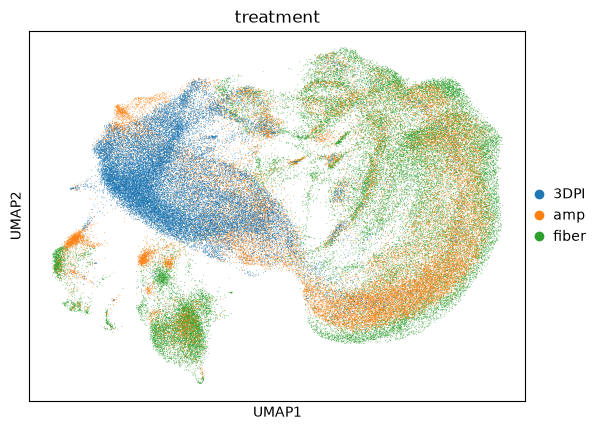

In [106]:
sc.pl.umap(diet_combine, color=["treatment"])

In [ ]:
for gene in ifng_genes:
    try:
        sc.pl.umap(diet_combine, color=gene, mask_obs=(diet_combine.obs["treatment"]=="fiber"))
    except KeyError as e:
        print(f"{gene} not present")

In [ ]:
#sc.pl.umap(diet_combine, color="Icam1")

## **Pseudobulking and Differential Gene Expression**

In [6]:
pdata_diet = dc.pp.pseudobulk(
    diet_combine,
    sample_col='treatment',
    groups_col='init_annotation',
    layer='counts',
    mode='sum'
)

In [7]:
pdata_live = dc.pp.pseudobulk(
    live_redo,
    sample_col='treatment',
    groups_col='init_annotation',
    layer='counts',
    mode='sum'
)

In [9]:
print(pdata_diet)
print(pdata_live)

AnnData object with n_obs × n_vars = 42 × 8497
    obs: 'treatment', 'init_annotation', 'predicted_doublet', 'psbulk_cells', 'psbulk_counts'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    layers: 'psbulk_props'
AnnData object with n_obs × n_vars = 18 × 15471
    obs: 'treatment', 'init_annotation', 'predicted_doublet', 'group', 'psbulk_cells', 'psbulk_counts'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    layers: 'psbulk_props'


In [ ]:
print(pdata_diet.obs["psbulk_counts"].value_counts())

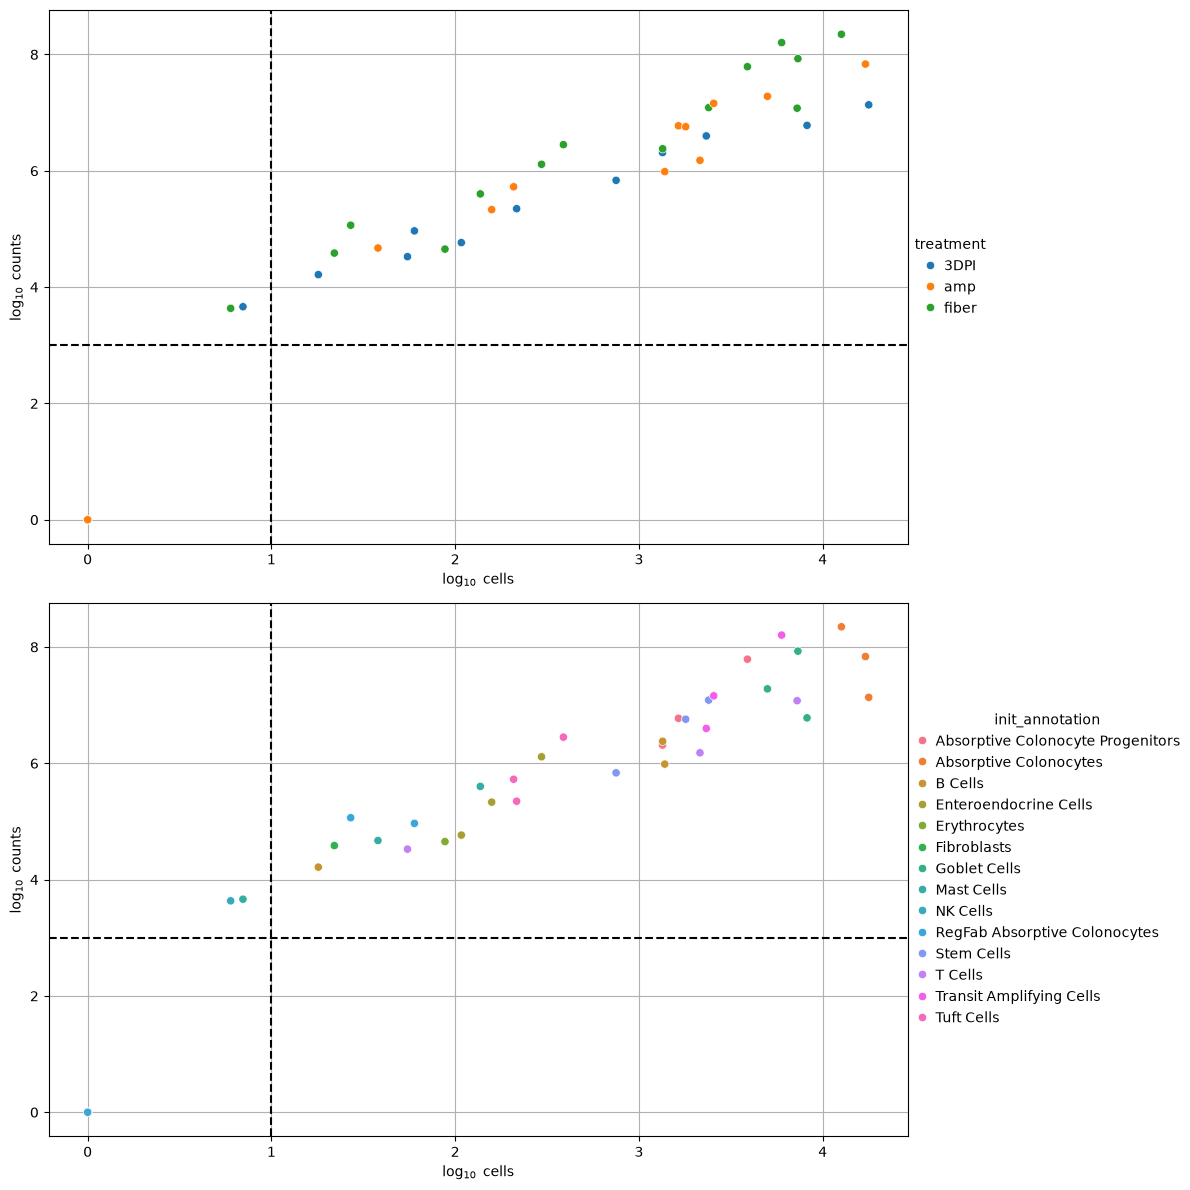

In [10]:
dc.pl.filter_samples(pdata_diet,
                     groupby=['treatment', 'init_annotation'],
                     figsize=(12, 12),
                     min_cells=10,
                     min_counts=1000)

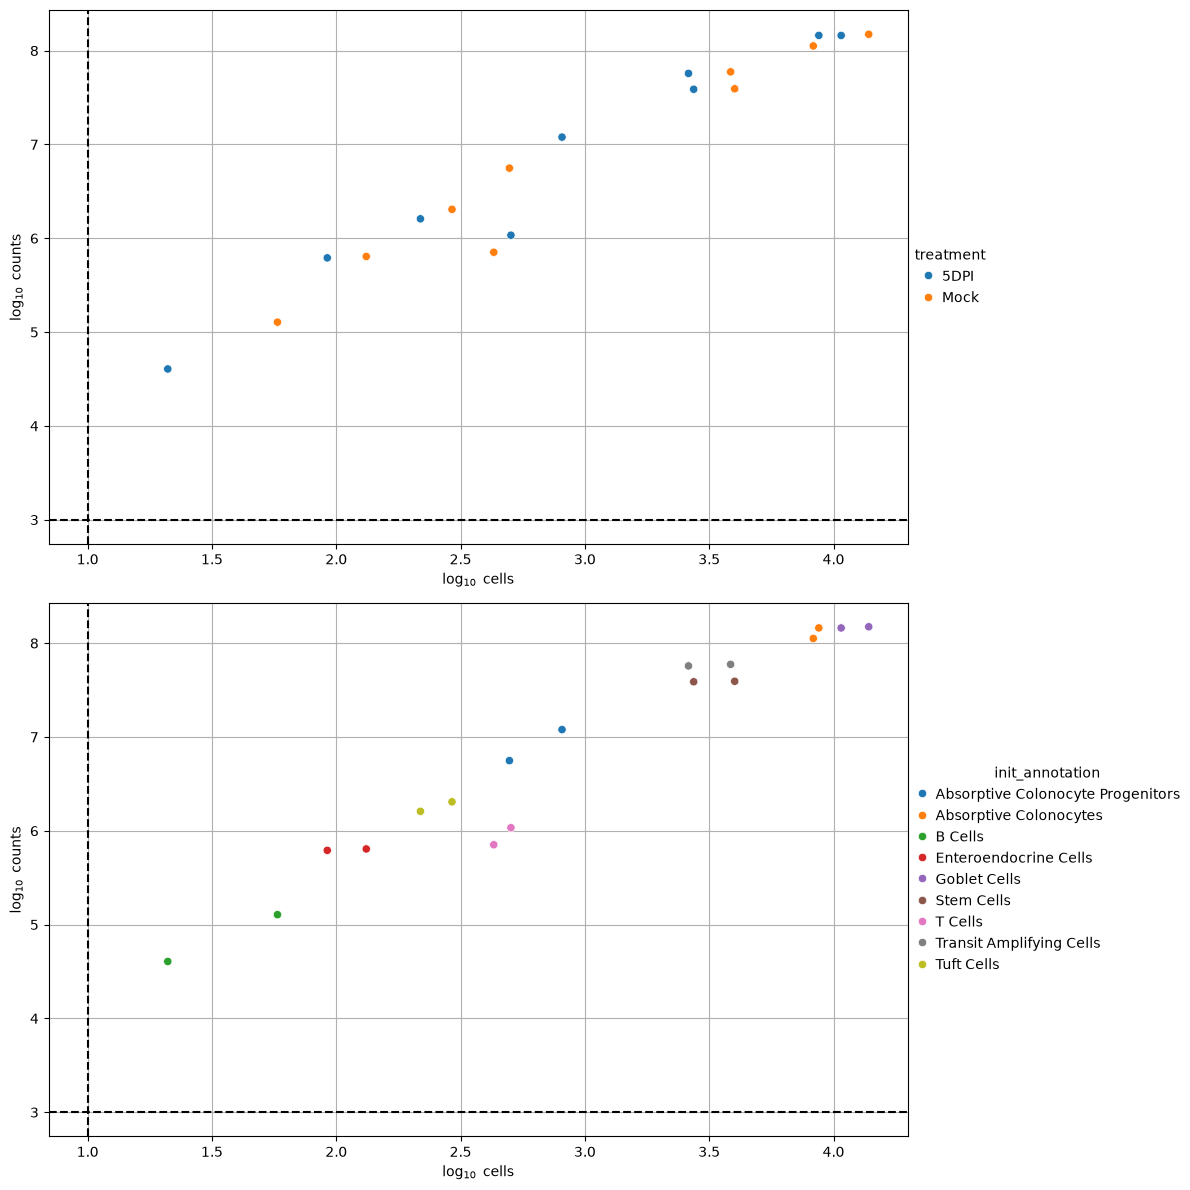

In [11]:
dc.pl.filter_samples(pdata_live,
                     groupby=['treatment', 'init_annotation'],
                     figsize=(12, 12),
                     min_cells=10,
                     min_counts=1000)

In [12]:
dc.pp.filter_samples(pdata_diet, min_cells=10, min_counts=1000, inplace=True)

In [8]:
# Store raw counts in layers
pdata_live.layers["counts"] = pdata_live.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata_live, target_sum=1e4)
sc.pp.log1p(pdata_live)
sc.pp.scale(pdata_live, max_value=10)
sc.tl.pca(pdata_live)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata_live, key="counts", inplace=True)

In [9]:
# Store raw counts in layers
pdata_diet.layers["counts"] = pdata_diet.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata_diet, target_sum=1e4)
sc.pp.log1p(pdata_diet)
sc.pp.scale(pdata_diet, max_value=10)
sc.tl.pca(pdata_diet)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata_diet, key="counts", inplace=True)

In [14]:
dc.tl.rankby_obsm(pdata_live,key='X_pca',obs_keys=["init_annotation"])

In [ ]:
print(pdata_diet.obs["treatment"].value_counts())

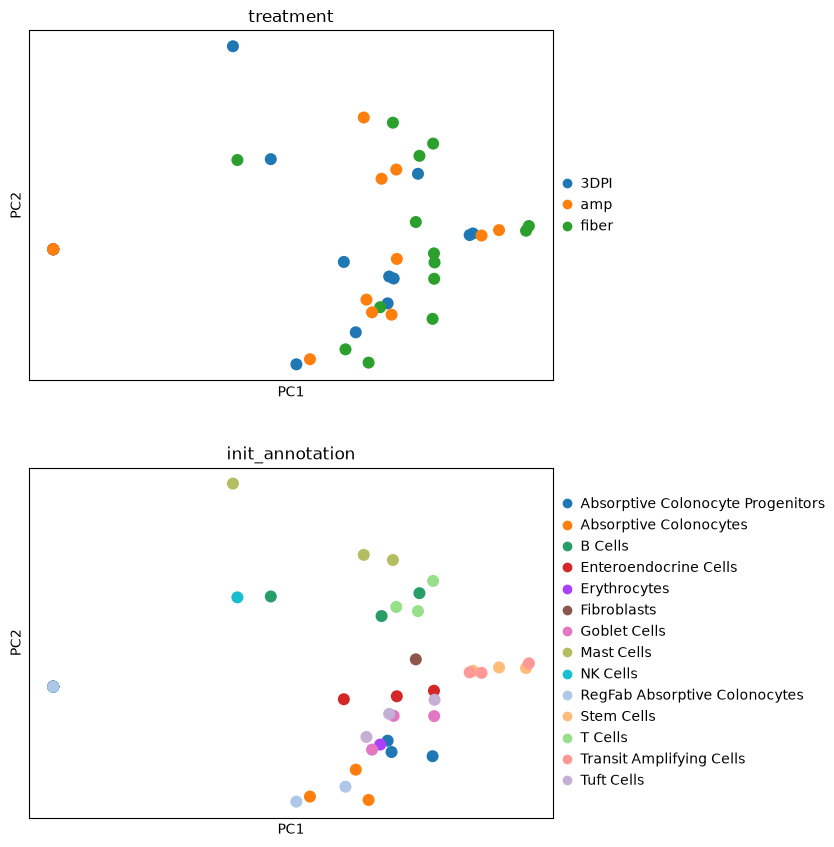

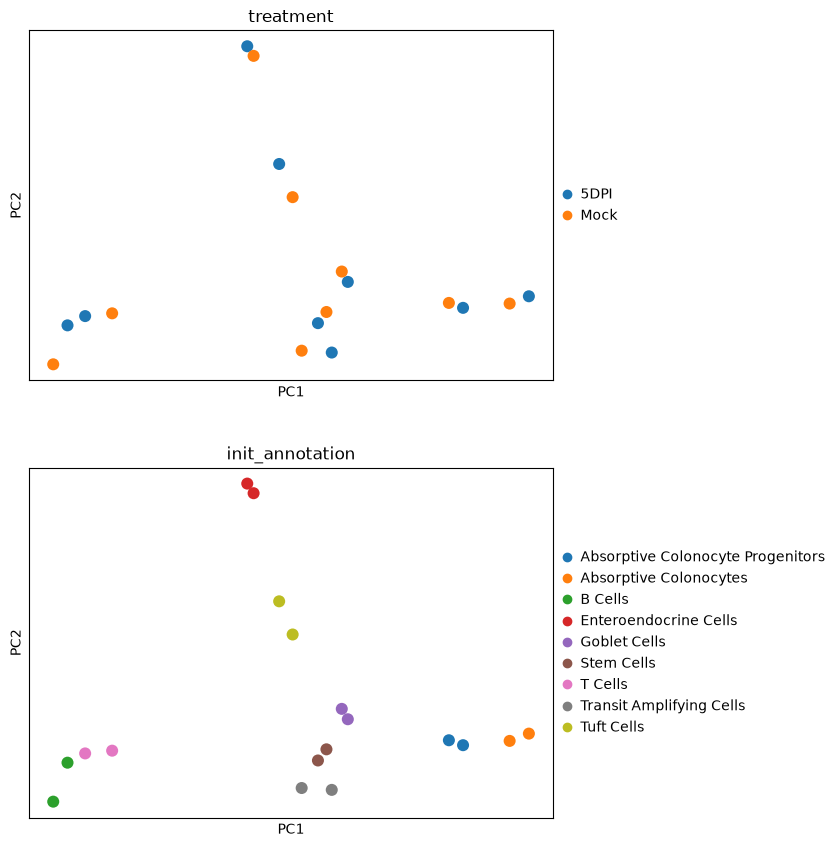

In [10]:
#dc.pl.obsm(adata=pdata_diet, return_fig=True, nvar=5, titles=["PC scores", "Adjusted p-values"], figsize=(10, 5))

sc.pl.pca(
    pdata_diet,
    color=["treatment", "init_annotation"],
    ncols=1,
    size=300,
    frameon=True,
)

sc.pl.pca(
    pdata_live,
    color=["treatment", "init_annotation"],
    ncols=1,
    size=300,
    frameon=True,
)

In [ ]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=pdata_live,
    design="~treatment",
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["treatment","5DPI","Mock"], inference=inference)
stat_res.summary()
#stat_res_a = DeseqStats(dds, contrast=["treatment","fiber","amp"], inference=inference)

# Compute Wald test
#output_f = stat_res_f.summary()
#output_a = stat_res_a.summary()

In [ ]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=pdata_diet,
    design="~treatment",
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res_f = DeseqStats(dds, contrast=["treatment","fiber","3DPI"], inference=inference)
stat_res_f.summary()
stat_res_a = DeseqStats(dds, contrast=["treatment","amp","3DPI"], inference=inference)
stat_res_a.summary()
stat_res_both = DeseqStats(dds, contrast=["treatment","fiber","amp"], inference=inference)
stat_res_both.summary()

In [37]:
output_f = stat_res_f.results_df[['log2FoldChange','padj']].sort_values(by='padj')
output_a = stat_res_a.results_df[['log2FoldChange','padj']].sort_values(by='padj')
output_both = stat_res_both.results_df[['log2FoldChange','padj']].sort_values(by='padj')
#output_f.to_csv("fiber_vs_5dpi_DEG.csv")
#output_a.to_csv("amp_vs_5dpi_DEG.csv")


In [86]:
stat_res_f.results_df.loc["Ifit3"]
#print(stat_res.results_df["padj"])

baseMean          1.624449e+00
log2FoldChange   -4.868876e+00
lfcSE             8.293525e-01
stat             -5.870696e+00
pvalue            4.339705e-09
padj              1.097455e-07
Name: Ifit3, dtype: float64

In [17]:
stat_res.results_df[['log2FoldChange','padj']].sort_values(by='padj').to_csv("Mock_vs_5DPI_scRNA_DEG.csv")

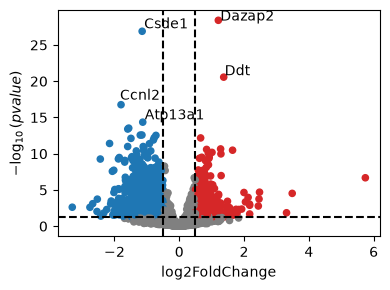

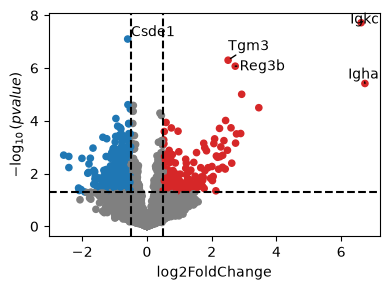

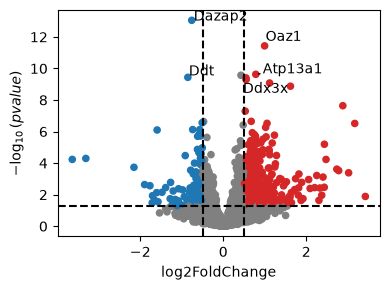

In [21]:
#volcano plots of differential genes

dc.pl.volcano(stat_res_f.results_df, x="log2FoldChange", y="pvalue")
dc.pl.volcano(stat_res_a.results_df, x="log2FoldChange", y="pvalue")
dc.pl.volcano(stat_res_both.results_df, x="log2FoldChange", y="pvalue")

## **GSEA and Transcription Factor ORA**

In [13]:
#Load dataset of transcription factors to use
collectri = dc.op.collectri(organism="mouse")
hallmark = dc.op.hallmark(organism="mouse")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,Maff
1,COAGULATION,Maff
2,HYPOXIA,Maff
3,TNFA_SIGNALING_VIA_NFKB,Maff
4,COMPLEMENT,Maff
...,...,...
7606,PANCREAS_BETA_CELLS,Stxbp1
7607,PANCREAS_BETA_CELLS,Elp4
7608,PANCREAS_BETA_CELLS,Gcg
7609,PANCREAS_BETA_CELLS,Pcsk2


In [ ]:
live_data = stat_res.results_df[["stat"]].T.rename(index={"stat": "5dpi.vs.mock"})
live_data_p = stat_res.results_df[["padj"]]
print(live_data_p)
valid_genes = []

for gene in live_data.columns.tolist():
    if gene in ifna_genes:
        if gene in ifng_genes:
            print(f"{gene}: {live_data[gene]["5dpi.vs.mock"]} in both")
        else:
            print(f"{gene}: {live_data[gene]["5dpi.vs.mock"]} only in ifna")
        valid_genes.append(gene)
    else:
        if gene in ifng_genes:
            print(f"{gene}: {live_data[gene]["5dpi.vs.mock"]} only in ifng")
            valid_genes.append(gene)

print(valid_genes)

for genea in ifna_genes:
    if genea not in valid_genes:
        ifna_genes.remove(genea)

for geneg in ifng_genes:
    if geneg not in valid_genes:
        ifng_genes.remove(geneg)

print(f"ifng: {ifng_genes}")
print(f"ifna: {ifna_genes}")

In [105]:
diet_f_data = stat_res_f.results_df[["stat"]].T.rename(index={"stat": "fiber.vs.3dpi"})
diet_f_data_p = stat_res_f.results_df[["padj"]].T.rename(index={"padj": "fiber.vs.3dpi"})
print(diet_f_data_p)
diet_a_data = stat_res_a.results_df[["stat"]].T.rename(index={"stat": "amp.vs.3dpi"})
diet_both_data = stat_res.results_df[["stat"]].T.rename(index={"stat": "fiber.vs.amp"})

prefixes = [diet_f_data,diet_a_data,diet_both_data]

valid_genes = []

for gene in diet_f_data_p.columns.tolist():
    mhc_match = re.search("H2-",gene)
    #if gene in ifna_genes:
    if mhc_match is not None:
        #if gene in ifng_genes:
        if float(diet_f_data_p[gene]["fiber.vs.3dpi"]) < 0.05:
            print(f"{gene}: {diet_f_data_p[gene]["fiber.vs.3dpi"]} in both")
            valid_genes.append(gene)
    #     else:
    #         if float(diet_f_data_p[gene]["fiber.vs.3dpi"]) < 0.05:
    #             print(f"{gene}: {diet_f_data_p[gene]["fiber.vs.3dpi"]} only in ifna")
    #             valid_genes.append(gene)
    # else:
    #     if gene in ifng_genes:
    #         if float(diet_f_data_p[gene]["fiber.vs.3dpi"]) < 0.05:
    #             print(f"{gene}: {diet_f_data_p[gene]["fiber.vs.3dpi"]} only in ifng")
    #             valid_genes.append(gene)

print(valid_genes)

# for genea in ifna_genes:
#     if genea not in valid_genes:
#         ifna_genes.remove(genea)

# for geneg in ifng_genes:
#     if geneg not in valid_genes:
#         ifng_genes.remove(geneg)

# print(f"ifng: {ifng_genes}")
# print(f"ifna: {ifna_genes}")

diet_tf_dict = {}

                 Lypla1     Tcea1   Atp6v1h    Rb1cc1    Pcmtd1    Vcpip1  \
fiber.vs.3dpi  0.450694  0.266124  0.914991  0.242367  0.096717  0.395085   

                       Sgk3     Cops5     Cspp1   Arfgef1  ...   mt-Atp8  \
fiber.vs.3dpi  1.861843e-07  0.005619  0.209734  0.005522  ...  0.000015   

               mt-Atp6    mt-Co3    mt-Nd3   mt-Nd4l    mt-Nd4    mt-Nd5  \
fiber.vs.3dpi   0.1472  0.018948  0.284178  0.000692  0.000003  0.000002   

                 mt-Nd6   mt-Cytb     Vamp7  
fiber.vs.3dpi  0.000012  0.000098  0.100891  

[1 rows x 8497 columns]
H2-Ab1: 9.036592578975806e-11 in both
H2-Aa: 0.00016995333472014207 in both
H2-Eb1: 3.619927165823876e-05 in both
H2-Q2: 0.0008468521374735426 in both
H2-Q7: 0.00023216081338090622 in both
H2-T23: 0.0074486403611979295 in both
H2-T3: 0.00013201988769193774 in both
['H2-Ab1', 'H2-Aa', 'H2-Eb1', 'H2-Q2', 'H2-Q7', 'H2-T23', 'H2-T3']


In [16]:
# Run

for idx, prefix in enumerate(prefixes):
    curr_tf, curr_padj = dc.mt.ulm(data=prefix, net=collectri)
    msk = (curr_padj.T < 0.05).iloc[:,0]
    curr_padj = curr_padj.loc[:,msk]
    diet_tf_dict[idx] = [curr_tf, curr_padj]

Text(0.5, 1.0, 'live')

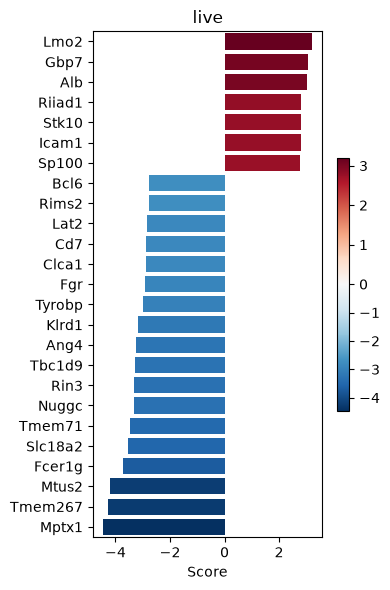

In [17]:
dc.pl.barplot(data=live_data,name="5dpi.vs.mock",figsize=(4,6))
plt.title("live")

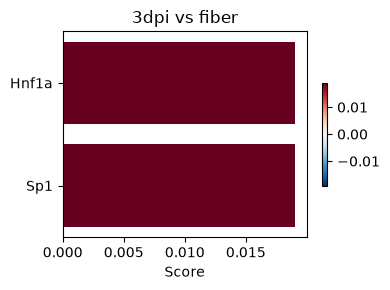

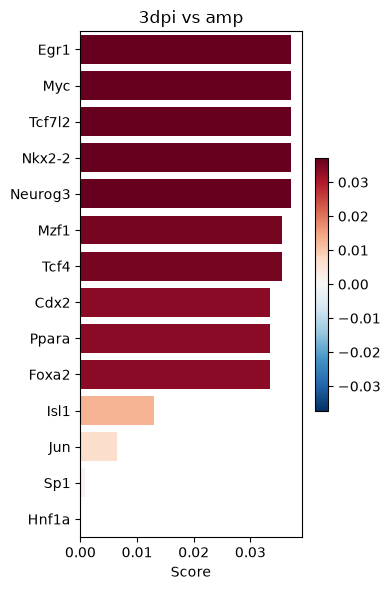

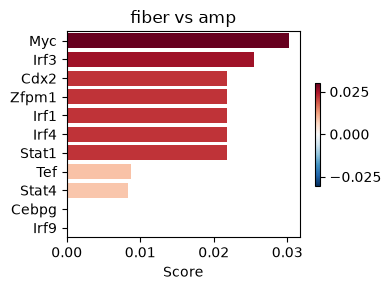

In [43]:
%matplotlib inline
for keys, vals in diet_tf_dict.items():
    match keys:
        case 0:
            dc.pl.barplot(data=vals[1], name="fiber.vs.3dpi", figsize=(4, 3))
            plt.title("3dpi vs fiber")
        case 1:
            dc.pl.barplot(data=vals[1], name="amp.vs.3dpi", figsize=(4, 6))
            plt.title("3dpi vs amp")
        case 2:
            dc.pl.barplot(data=vals[1], name="fiber.vs.amp", figsize=(4, 3))
            plt.title("fiber vs amp")
    

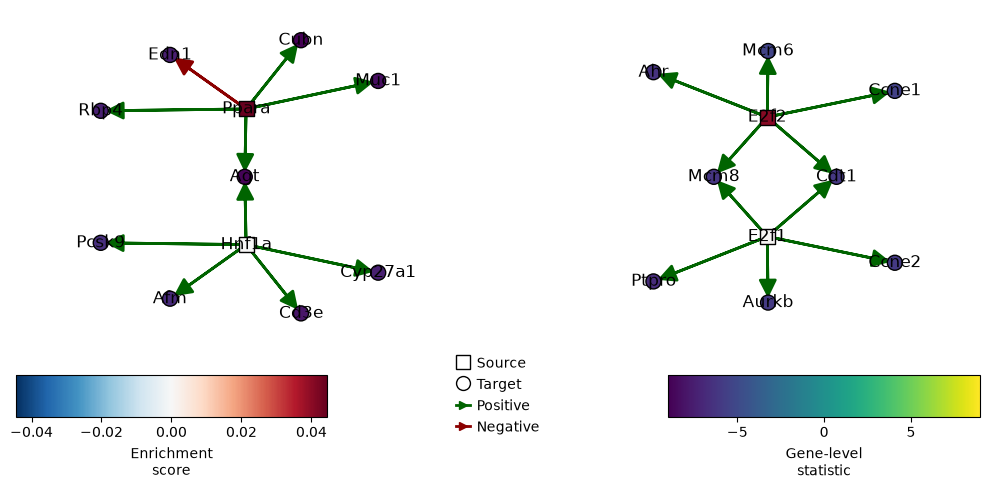

In [50]:
dc.pl.network(
    net=collectri,
    data=diet_f_data,
    score=diet_tf_dict[0][1],
    sources=["Ppara","E2f2","E2f1","Hnf1a"],
    targets=5,
    figsize=(10, 5),
    vcenter=True,
    by_abs=True,
    size_node=15,
    t_label="Gene-level\nstatistic",
)

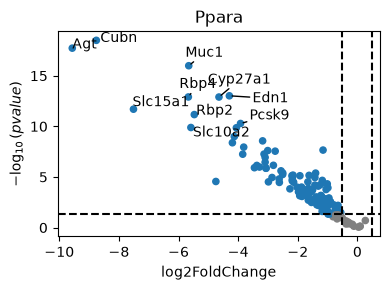

In [52]:
dc.pl.volcano(
    data=stat_res_f.results_df,
    x="log2FoldChange",
    y="pvalue",
    net=collectri,
    name="Ppara",
    top=10,
)

In [18]:
#dc.op.show_resources() #use to see all available options for database pathway scoring
# Run
hm_acts, hm_padj = dc.mt.ulm(data=live_data, net=hallmark)

# Filter by sign padj
msk = (hm_padj.T < 0.05).iloc[:, 0]
hm_acts = hm_acts.loc[:, msk]

hm_acts

,ADIPOGENESIS,APICAL_JUNCTION,CHOLESTEROL_HOMEOSTASIS,E2F_TARGETS,G2M_CHECKPOINT,HEME_METABOLISM,HYPOXIA,INFLAMMATORY_RESPONSE,INTERFERON_ALPHA_RESPONSE,INTERFERON_GAMMA_RESPONSE,MTORC1_SIGNALING,MYC_TARGETS_V1,OXIDATIVE_PHOSPHORYLATION,TNFA_SIGNALING_VIA_NFKB
5dpi.vs.mock,2.919604,3.025431,3.603265,-6.641705,-5.785392,2.927385,2.989851,3.686368,9.762213,10.700856,2.7494,-4.576108,3.503227,4.396176


In [19]:
#dc.op.show_resources() #use to see all available options for database pathway scoring
# Run
hm_acts_f, hm_padj_f = dc.mt.ulm(data=diet_f_data, net=hallmark)
# Filter by sign padj
hm_acts_f = hm_acts_f.loc[:, (hm_padj_f.T < 0.05).iloc[:, 0]]

# Run
hm_acts_a, hm_padj_a = dc.mt.ulm(data=diet_a_data, net=hallmark)
# Filter by sign padj
hm_acts_a = hm_acts_a.loc[:, (hm_padj_a.T < 0.05).iloc[:, 0]]

# Run
hm_acts_both, hm_padj_both = dc.mt.ulm(data=diet_both_data, net=hallmark)
# Filter by sign padj
hm_acts_both = hm_acts_both.loc[:, (hm_padj_both.T < 0.05).iloc[:, 0]]


Text(0.5, 1.0, 'fiber vs amp')

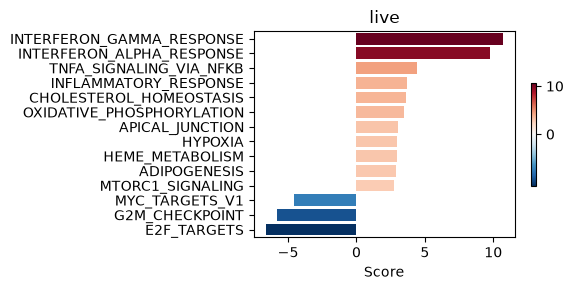

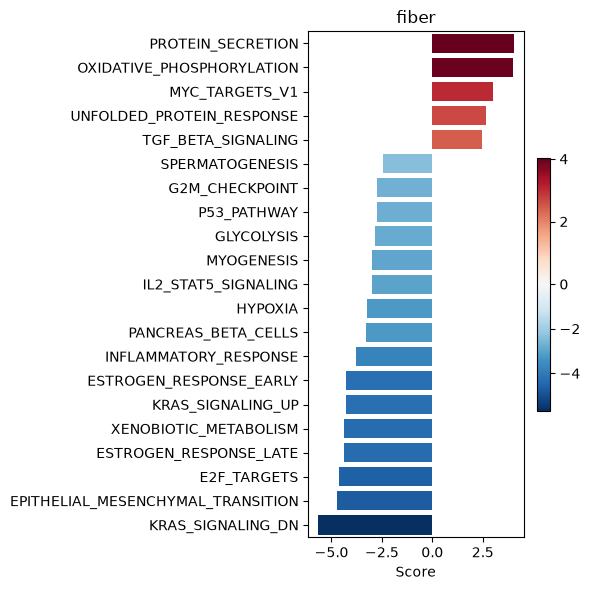

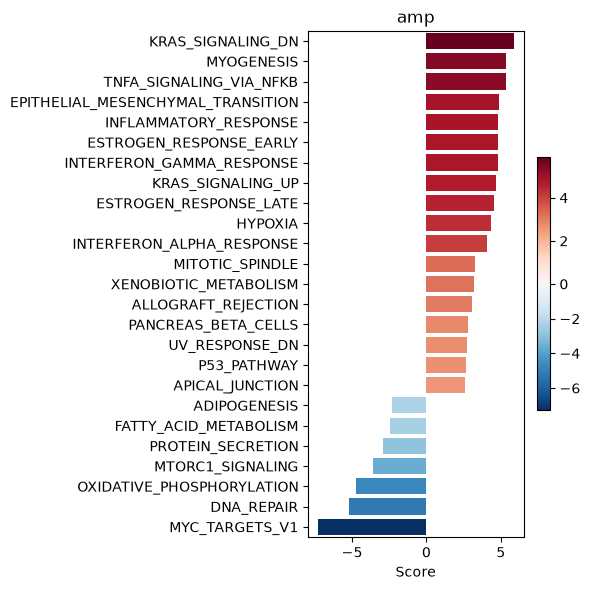

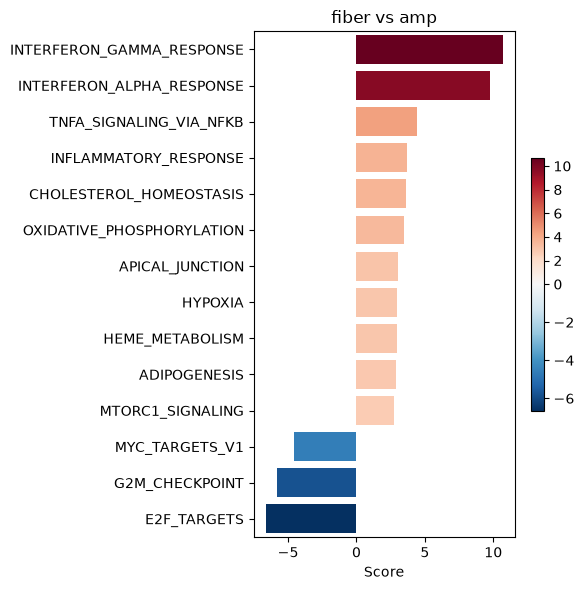

In [20]:
dc.pl.barplot(data=hm_acts, name="5dpi.vs.mock", figsize=(6, 3))
plt.title("live")
dc.pl.barplot(data=hm_acts_f, name="fiber.vs.3dpi", figsize=(6, 6))
plt.title("fiber")
dc.pl.barplot(data=hm_acts_a, name="amp.vs.3dpi", figsize=(6, 6))
plt.title("amp")
dc.pl.barplot(data=hm_acts_both, name="fiber.vs.amp", figsize=(6, 6))
plt.title("fiber vs amp")

In [72]:
ir_hallmark = hallmark[hallmark['source'] == "INFLAMMATORY_RESPONSE"]

In [23]:
#print all genes from a given hallmark pathway
pd.set_option('display.max_rows',None)
ifna_genes = hallmark['target'][hallmark['source']=="INTERFERON_ALPHA_RESPONSE"].tolist()
ifng_genes = hallmark['target'][hallmark['source']=="INTERFERON_GAMMA_RESPONSE"].tolist()